# 🩺 Previsão de Propensão ao Diabetes
## Machine Learning Supervisionado — Análise de Ingestão Diária de Alimentos

Este notebook utiliza algoritmos de **aprendizado de máquina supervisionado** para prever a propensão de uma pessoa desenvolver diabetes com base em seus hábitos alimentares diários.

### Campos de entrada:
| Campo | Descrição | Unidade |
|---|---|---|
| `calorias_totais` | Total de calorias ingeridas no dia | kcal |
| `carboidratos_g` | Quantidade de carboidratos | gramas |
| `acucar_g` | Quantidade de açúcar (inclui açúcar livre) | gramas |
| `fibras_g` | Quantidade de fibras alimentares | gramas |
| `gordura_saturada_g` | Gordura saturada ingerida | gramas |
| `proteina_g` | Quantidade de proteínas | gramas |
| `sodio_mg` | Sódio ingerido | miligramas |
| `indice_glicemico_medio` | IG médio dos alimentos do dia (0–100) | score |
| `refeicoes_por_dia` | Número de refeições realizadas no dia | qtd |
| `consumo_agua_L` | Litros de água ingeridos | litros |
| `atividade_fisica_min` | Minutos de atividade física no dia | min |
| `imc` | Índice de Massa Corporal da pessoa | kg/m² |
| `historico_familiar` | Histórico familiar de diabetes (0=Não, 1=Sim) | binário |
| `idade` | Idade da pessoa | anos |
| `diabetico` | **Target**: 0 = Não diabético, 1 = Diabético | binário |

---
## 📦 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Para salvar o modelo
import joblib

print('✅ Bibliotecas importadas com sucesso!')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

✅ Bibliotecas importadas com sucesso!
   pandas 2.2.3 | numpy 2.0.0


---
## 📊 2. Carregamento dos Dados

> **Opção A** — Carregar seu próprio arquivo CSV  
> **Opção B** — Usar dados sintéticos gerados automaticamente para demonstração

In [2]:
# ============================================================
# OPÇÃO A: Carregue seu próprio CSV
# Descomente a linha abaixo e informe o caminho do arquivo:
# df = pd.read_csv('seu_arquivo.csv')
# ============================================================

# OPÇÃO B: Gerar dataset sintético para demonstração
np.random.seed(42)
n = 1000

idade            = np.random.randint(18, 75, n)
imc              = np.round(np.random.normal(27, 5, n).clip(15, 50), 1)
historico_fam    = np.random.binomial(1, 0.3, n)
calorias         = np.random.normal(2100, 400, n).clip(1200, 4000).astype(int)
carboidratos     = np.round(np.random.normal(260, 60, n).clip(50, 500), 1)
acucar           = np.round(np.random.normal(60, 25, n).clip(5, 200), 1)
fibras           = np.round(np.random.normal(20, 8, n).clip(2, 60), 1)
gordura_sat      = np.round(np.random.normal(22, 8, n).clip(2, 60), 1)
proteina         = np.round(np.random.normal(80, 25, n).clip(20, 200), 1)
sodio            = np.round(np.random.normal(2200, 700, n).clip(500, 5000), 0)
ig_medio         = np.round(np.random.normal(55, 15, n).clip(10, 100), 1)
refeicoes        = np.random.randint(1, 7, n)
agua             = np.round(np.random.normal(2.0, 0.7, n).clip(0.5, 5.0), 1)
atividade_fisica = np.random.randint(0, 120, n)

# Criar score de risco baseado nos fatores mais relevantes
risco = (
    0.04  * (imc - 22) +
    0.03  * (acucar - 40) +
    0.02  * (ig_medio - 50) +
    0.015 * (carboidratos - 200) +
    0.01  * (gordura_sat - 15) +
    0.8   * historico_fam +
    0.02  * (idade - 30) -
    0.03  * fibras -
    0.01  * atividade_fisica +
    np.random.normal(0, 0.5, n)   # ruído
)
prob_diabetes = 1 / (1 + np.exp(-risco))
diabetico = (prob_diabetes > 0.5).astype(int)

df = pd.DataFrame({
    'idade':                 idade,
    'imc':                   imc,
    'historico_familiar':    historico_fam,
    'calorias_totais':       calorias,
    'carboidratos_g':        carboidratos,
    'acucar_g':              acucar,
    'fibras_g':              fibras,
    'gordura_saturada_g':    gordura_sat,
    'proteina_g':            proteina,
    'sodio_mg':              sodio,
    'indice_glicemico_medio': ig_medio,
    'refeicoes_por_dia':     refeicoes,
    'consumo_agua_L':        agua,
    'atividade_fisica_min':  atividade_fisica,
    'diabetico':             diabetico
})

print(f'✅ Dataset carregado: {df.shape[0]} registros × {df.shape[1]} colunas')
print(f'   Distribuição do target → Não diabético: {(df.diabetico==0).sum()} | Diabético: {(df.diabetico==1).sum()}')
df.head()

✅ Dataset carregado: 1000 registros × 15 colunas
   Distribuição do target → Não diabético: 192 | Diabético: 808


,idade,imc,historico_familiar,calorias_totais,carboidratos_g,acucar_g,fibras_g,gordura_saturada_g,proteina_g,sodio_mg,indice_glicemico_medio,refeicoes_por_dia,consumo_agua_L,atividade_fisica_min,diabetico
0,56,16.7,0,2142,260.7,14.0,19.2,20.3,97.2,2349.0,66.7,3,2.2,12,1
1,69,26.6,0,2333,432.1,82.3,13.3,14.5,68.9,2193.0,54.0,2,2.8,92,1
2,46,20.5,1,2890,159.9,45.3,26.0,32.7,58.7,2078.0,54.8,1,2.2,23,0
3,32,30.3,1,1474,323.5,77.5,25.2,29.4,63.9,3137.0,38.4,2,2.3,101,1
4,60,28.8,0,2746,249.6,60.6,27.8,17.2,97.5,1706.0,50.5,4,2.7,11,1


---
## 🔍 3. Análise Exploratória dos Dados (EDA)

In [3]:
print('=== Estatísticas Descritivas ===')
df.describe().round(2)

=== Estatísticas Descritivas ===


,idade,imc,historico_familiar,calorias_totais,carboidratos_g,acucar_g,fibras_g,gordura_saturada_g,proteina_g,sodio_mg,indice_glicemico_medio,refeicoes_por_dia,consumo_agua_L,atividade_fisica_min,diabetico
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,46.25,27.25,0.30,2099.35,258.75,59.72,19.62,21.76,80.30,2224.04,54.64,3.46,1.98,59.23,0.81
std,16.29,4.95,0.46,394.21,61.61,24.25,8.00,8.31,25.59,687.55,14.55,1.72,0.71,34.52,0.39
min,18.00,15.00,0.00,1200.00,79.50,5.00,2.00,2.00,20.00,500.00,10.00,1.00,0.50,0.00,0.00
25%,33.00,23.90,0.00,1823.75,216.52,43.38,14.10,16.00,62.58,1768.75,44.68,2.00,1.50,28.75,1.00
50%,46.00,27.20,0.00,2099.00,259.50,60.35,19.50,21.70,79.55,2219.50,55.05,3.00,2.00,61.00,1.00
75%,60.25,30.40,1.00,2368.00,296.42,76.43,25.10,27.60,98.10,2674.50,64.40,5.00,2.50,89.00,1.00
max,74.00,42.40,1.00,3670.00,454.60,137.80,44.80,50.20,154.80,4564.00,98.70,6.00,4.20,119.00,1.00


In [4]:
print('=== Valores Nulos por Coluna ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else '✅ Nenhum valor nulo encontrado!')

=== Valores Nulos por Coluna ===
✅ Nenhum valor nulo encontrado!


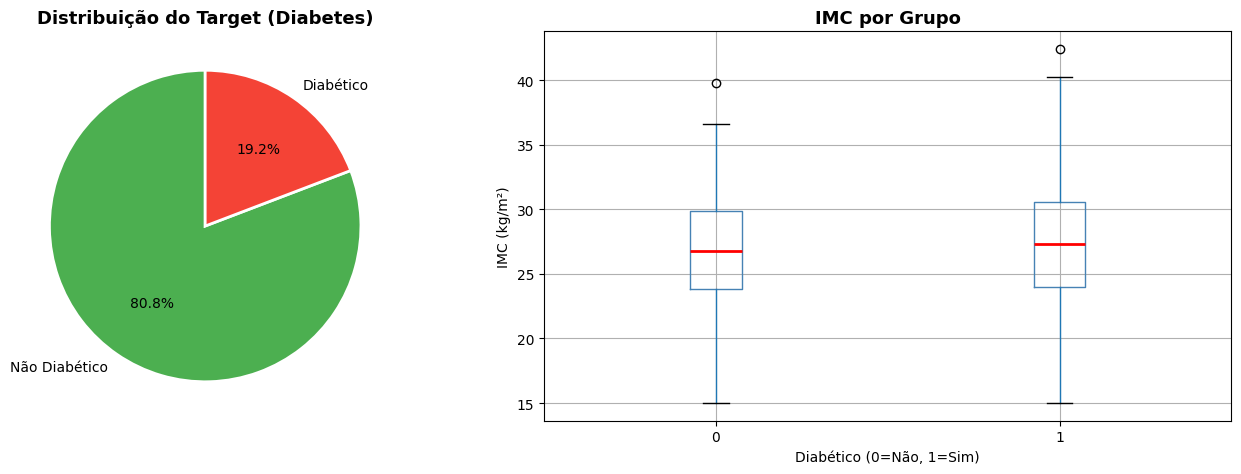

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição do target
target_counts = df['diabetico'].value_counts()
colors = ['#4CAF50', '#F44336']
axes[0].pie(target_counts, labels=['Não Diabético', 'Diabético'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribuição do Target (Diabetes)', fontsize=13, fontweight='bold')

# Boxplot: IMC vs Diabetes
df.boxplot(column='imc', by='diabetico', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('IMC por Grupo', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Diabético (0=Não, 1=Sim)')
axes[1].set_ylabel('IMC (kg/m²)')
plt.suptitle('')
plt.tight_layout()
plt.show()

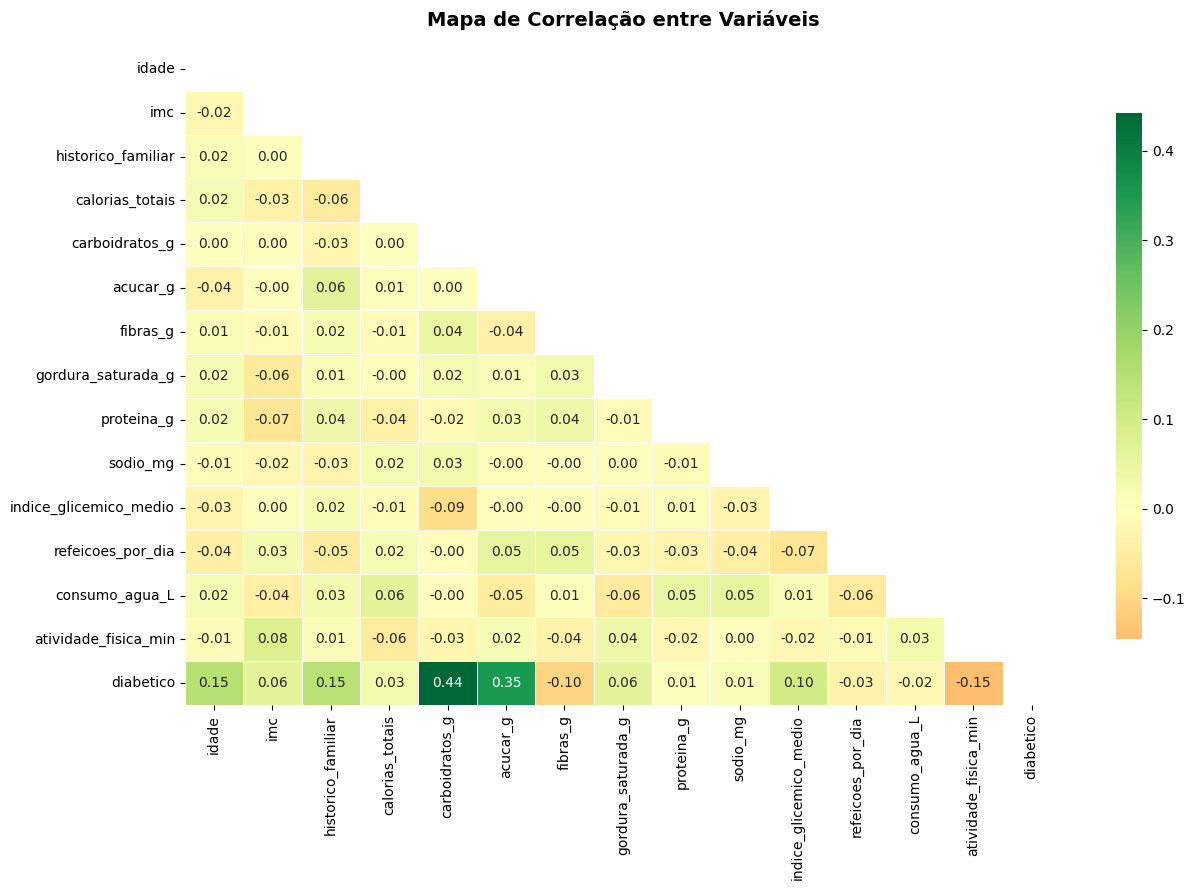

In [6]:
fig, ax = plt.subplots(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de Correlação entre Variáveis', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

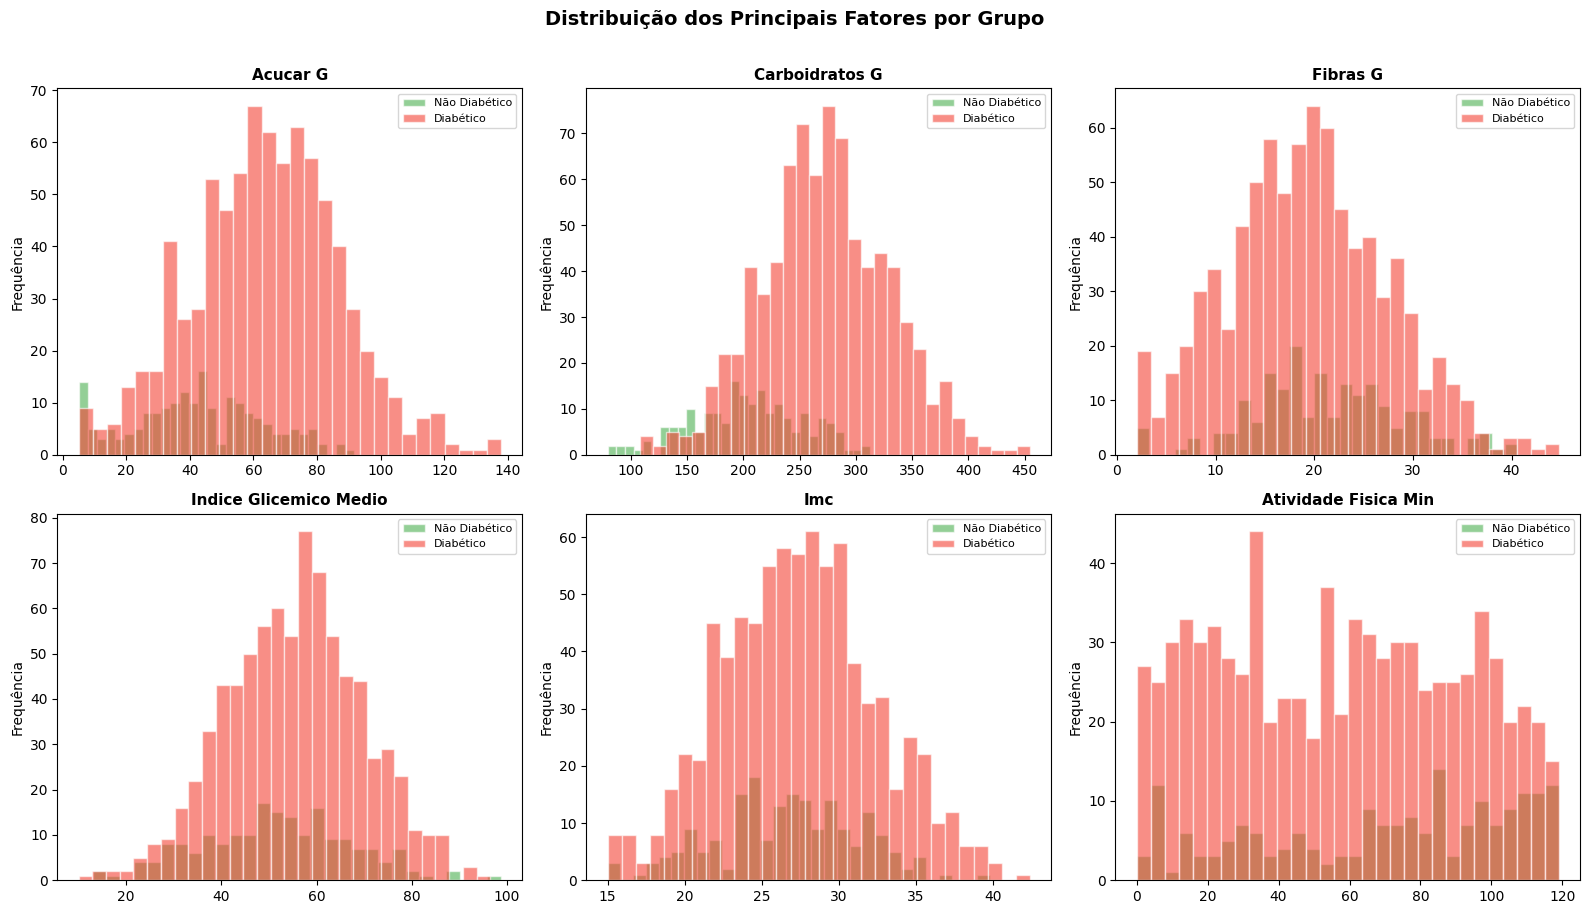

In [7]:
# Distribuição dos principais nutrientes por grupo
features_plot = ['acucar_g', 'carboidratos_g', 'fibras_g', 'indice_glicemico_medio',
                 'imc', 'atividade_fisica_min']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    for label, color, name in [(0, '#4CAF50', 'Não Diabético'), (1, '#F44336', 'Diabético')]:
        axes[i].hist(df[df['diabetico']==label][feat], bins=30,
                     alpha=0.6, color=color, label=name, edgecolor='white')
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição dos Principais Fatores por Grupo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## ⚙️ 4. Pré-processamento

In [8]:
# Separar features e target
FEATURES = [
    'idade', 'imc', 'historico_familiar',
    'calorias_totais', 'carboidratos_g', 'acucar_g', 'fibras_g',
    'gordura_saturada_g', 'proteina_g', 'sodio_mg',
    'indice_glicemico_medio', 'refeicoes_por_dia',
    'consumo_agua_L', 'atividade_fisica_min'
]
TARGET = 'diabetico'

X = df[FEATURES]
y = df[TARGET]

# Divisão treino/teste (80/20 estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalização (StandardScaler)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'✅ Pré-processamento concluído!')
print(f'   Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

✅ Pré-processamento concluído!
   Treino: 800 amostras | Teste: 200 amostras


---
## 🤖 5. Treinamento dos Modelos

Serão treinados e comparados **5 algoritmos**:
- Regressão Logística
- Árvore de Decisão
- Random Forest
- Gradient Boosting
- SVM (Support Vector Machine)

In [9]:
models = {
    'Regressão Logística':  LogisticRegression(max_iter=1000, random_state=42),
    'Árvore de Decisão':    DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                  SVC(probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    cv   = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc').mean()

    results[name] = {'Acurácia': acc, 'AUC-ROC': auc, 'CV AUC (5-fold)': cv,
                     'model': model, 'y_pred': y_pred, 'y_proba': y_proba}
    print(f'  {name:<25} → Acurácia: {acc:.3f} | AUC: {auc:.3f} | CV-AUC: {cv:.3f}')

print('\n✅ Todos os modelos treinados!')

  Regressão Logística       → Acurácia: 0.935 | AUC: 0.973 | CV-AUC: 0.973
  Árvore de Decisão         → Acurácia: 0.855 | AUC: 0.799 | CV-AUC: 0.748
  Random Forest             → Acurácia: 0.870 | AUC: 0.938 | CV-AUC: 0.933
  Gradient Boosting         → Acurácia: 0.900 | AUC: 0.952 | CV-AUC: 0.938
  SVM                       → Acurácia: 0.930 | AUC: 0.965 | CV-AUC: 0.958

✅ Todos os modelos treinados!


---
## 📈 6. Avaliação e Comparação dos Modelos

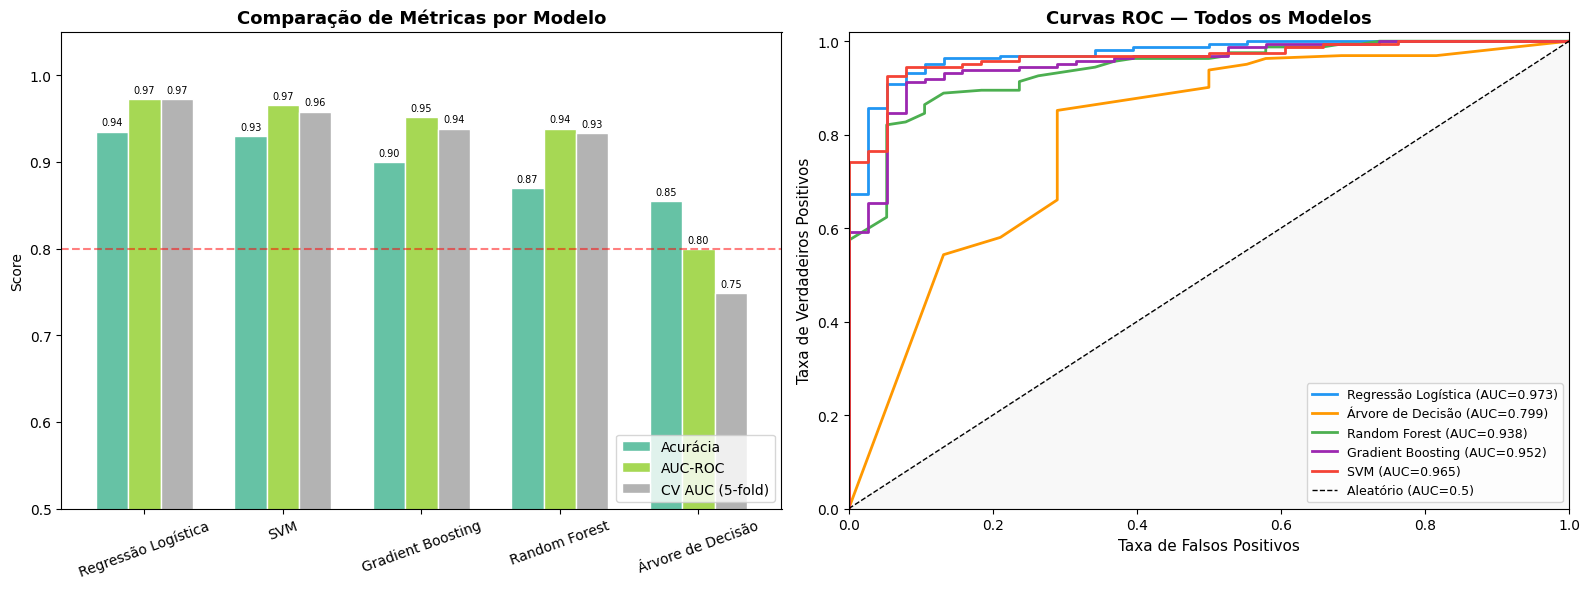

                     Acurácia  AUC-ROC  CV AUC (5-fold)
Regressão Logística     0.935   0.9725           0.9727
SVM                     0.930   0.9651           0.9580
Gradient Boosting       0.900   0.9519           0.9384
Random Forest           0.870   0.9384           0.9328
Árvore de Decisão       0.855   0.7991           0.7482


In [10]:
df_results = pd.DataFrame({
    k: {m: v[m] for m in ['Acurácia', 'AUC-ROC', 'CV AUC (5-fold)']}
    for k, v in results.items()
}).T.sort_values('AUC-ROC', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras comparativo
df_results[['Acurácia', 'AUC-ROC', 'CV AUC (5-fold)']].plot(
    kind='bar', ax=axes[0], colormap='Set2', edgecolor='white', width=0.7
)
axes[0].set_title('Comparação de Métricas por Modelo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.05)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(loc='lower right')
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='Referência 0.80')
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():.2f}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005),
                     ha='center', va='bottom', fontsize=7)

# Curvas ROC
colors_roc = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0', '#F44336']
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={res['AUC-ROC']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC=0.5)')
axes[1].fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('Taxa de Falsos Positivos', fontsize=11)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos', fontsize=11)
axes[1].set_title('Curvas ROC — Todos os Modelos', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()
print(df_results.round(4))

🏆 Melhor modelo: Regressão Logística (AUC-ROC = 0.9725)


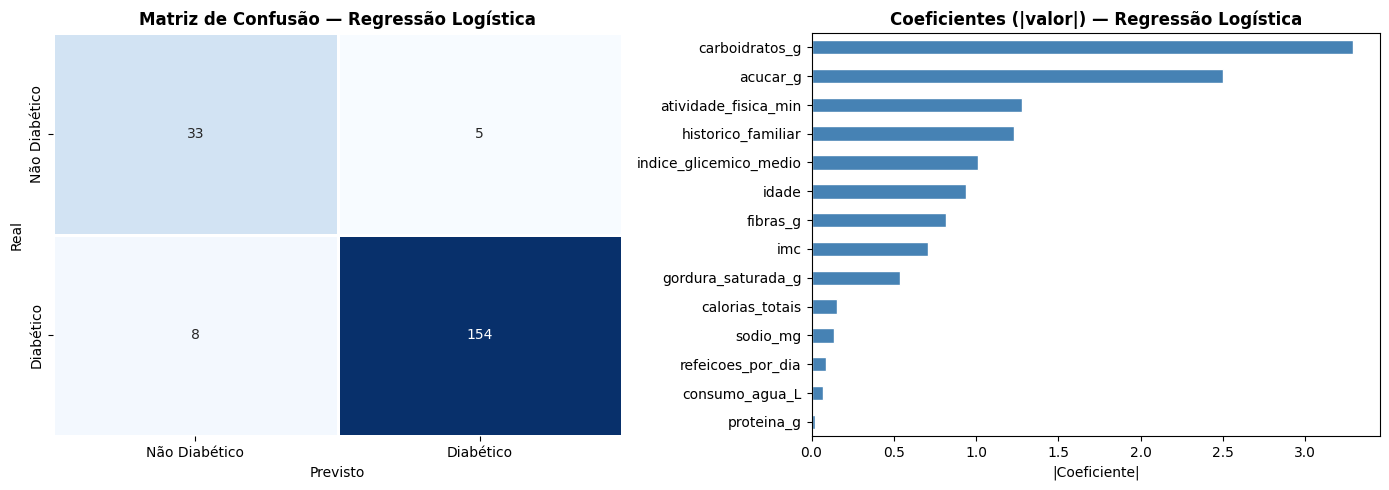


=== Relatório de Classificação Completo ===
               precision    recall  f1-score   support

Não Diabético       0.80      0.87      0.84        38
    Diabético       0.97      0.95      0.96       162

     accuracy                           0.94       200
    macro avg       0.89      0.91      0.90       200
 weighted avg       0.94      0.94      0.94       200



In [11]:
# Selecionar o melhor modelo automaticamente
best_name = df_results['AUC-ROC'].idxmax()
best = results[best_name]
print(f'🏆 Melhor modelo: {best_name} (AUC-ROC = {best["AUC-ROC"]:.4f})')

# Matriz de Confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não Diabético', 'Diabético'],
            yticklabels=['Não Diabético', 'Diabético'],
            linewidths=1, linecolor='white', cbar=False)
axes[0].set_title(f'Matriz de Confusão — {best_name}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Previsto')

# Importância das features (se disponível)
model_obj = best['model']
if hasattr(model_obj, 'feature_importances_'):
    importances = pd.Series(model_obj.feature_importances_, index=FEATURES).sort_values(ascending=True)
    importances.plot(kind='barh', ax=axes[1], colormap='viridis', edgecolor='white')
    axes[1].set_title(f'Importância das Features — {best_name}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Importância')
elif hasattr(model_obj, 'coef_'):
    coefs = pd.Series(np.abs(model_obj.coef_[0]), index=FEATURES).sort_values(ascending=True)
    coefs.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
    axes[1].set_title(f'Coeficientes (|valor|) — {best_name}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('|Coeficiente|')
else:
    axes[1].text(0.5, 0.5, 'Importância não disponível\npara este modelo',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.show()

print('\n=== Relatório de Classificação Completo ===')
print(classification_report(y_test, best['y_pred'],
                             target_names=['Não Diabético', 'Diabético']))

---
## 🔧 7. Otimização de Hiperparâmetros (GridSearchCV)
Aplicado sobre o melhor modelo para maximizar o AUC-ROC.

In [12]:
# Grid de hiperparâmetros por modelo
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    'Regressão Logística': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'saga']
    },
    'Árvore de Decisão': {
        'max_depth': [4, 6, 8, None],
        'min_samples_split': [2, 5, 10]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    }
}

if best_name in param_grids:
    print(f'⚙️  Otimizando hiperparâmetros para: {best_name} ...')
    base_model = type(best['model'])(random_state=42) if hasattr(best['model'], 'random_state') else type(best['model'])()
    grid = GridSearchCV(base_model, param_grids[best_name], cv=5,
                        scoring='roc_auc', n_jobs=-1, verbose=0)
    grid.fit(X_train_sc, y_train)

    y_pred_opt  = grid.best_estimator_.predict(X_test_sc)
    y_proba_opt = grid.best_estimator_.predict_proba(X_test_sc)[:, 1]

    print(f'   Melhores parâmetros: {grid.best_params_}')
    print(f'   AUC antes: {best["AUC-ROC"]:.4f} → AUC após otimização: {roc_auc_score(y_test, y_proba_opt):.4f}')
    final_model = grid.best_estimator_
else:
    print('ℹ️ Usando modelo sem otimização adicional.')
    final_model = best['model']

⚙️  Otimizando hiperparâmetros para: Regressão Logística ...
   Melhores parâmetros: {'C': 0.1, 'solver': 'lbfgs'}
   AUC antes: 0.9725 → AUC após otimização: 0.9735


---
## 🩺 8. Previsão para Novos Pacientes
Insira os dados de consumo diário de um paciente para obter a **probabilidade de diabetes**.

In [13]:
def prever_diabetes(dados_paciente: dict, modelo, scaler, features) -> dict:
    """
    Prevê a propensão ao diabetes com base nos dados diários de alimentação.

    Parâmetros:
        dados_paciente : dict com os campos de features
        modelo         : modelo treinado
        scaler         : StandardScaler ajustado
        features       : lista de features na ordem correta

    Retorna:
        dict com probabilidade, classificação e nível de risco
    """
    entrada = pd.DataFrame([dados_paciente])[features]
    entrada_sc = scaler.transform(entrada)
    prob = modelo.predict_proba(entrada_sc)[0][1]
    classe = modelo.predict(entrada_sc)[0]

    if prob < 0.30:   risco = '🟢 BAIXO'
    elif prob < 0.60: risco = '🟡 MODERADO'
    elif prob < 0.80: risco = '🟠 ALTO'
    else:             risco = '🔴 MUITO ALTO'

    return {'probabilidade_diabetes': round(prob * 100, 2),
            'classificacao': 'Diabético' if classe == 1 else 'Não Diabético',
            'nivel_risco': risco}


# ──────────────────────────────────────────────
# ✏️  PREENCHA COM OS DADOS REAIS DO PACIENTE:
# ──────────────────────────────────────────────
paciente_exemplo = {
    'idade':                  45,
    'imc':                    31.5,
    'historico_familiar':     1,       # 1 = Sim, 0 = Não
    'calorias_totais':        2800,
    'carboidratos_g':         340,
    'acucar_g':               95,
    'fibras_g':               12,
    'gordura_saturada_g':     30,
    'proteina_g':             70,
    'sodio_mg':               3100,
    'indice_glicemico_medio': 72,
    'refeicoes_por_dia':      3,
    'consumo_agua_L':         1.5,
    'atividade_fisica_min':   10
}

resultado = prever_diabetes(paciente_exemplo, final_model, scaler, FEATURES)

print('=' * 50)
print('       RESULTADO DA ANÁLISE DE RISCO')
print('=' * 50)
for chave, valor in resultado.items():
    label = chave.replace('_', ' ').title()
    sufixo = ' %' if 'probabilidade' in chave else ''
    print(f'  {label:<28}: {valor}{sufixo}')
print('=' * 50)

       RESULTADO DA ANÁLISE DE RISCO
  Probabilidade Diabetes      : 100.0 %
  Classificacao               : Diabético
  Nivel Risco                 : 🔴 MUITO ALTO


---
## 💾 9. Salvar Modelo Final

In [14]:
joblib.dump(final_model, 'modelo_diabetes.pkl')
joblib.dump(scaler,      'scaler_diabetes.pkl')

print('✅ Modelo salvo em: modelo_diabetes.pkl')
print('✅ Scaler salvo em: scaler_diabetes.pkl')

# Para carregar o modelo depois:
# modelo_carregado = joblib.load('modelo_diabetes.pkl')
# scaler_carregado = joblib.load('scaler_diabetes.pkl')

✅ Modelo salvo em: modelo_diabetes.pkl
✅ Scaler salvo em: scaler_diabetes.pkl


---
## 📋 10. Resumo Final

| Etapa | Descrição |
|---|---|
| **Dados** | 14 features alimentares/clínicas + 1 target binário |
| **Divisão** | 80% treino / 20% teste (estratificado) |
| **Normalização** | StandardScaler |
| **Modelos testados** | Regressão Logística, Árvore, Random Forest, Gradient Boosting, SVM |
| **Métrica principal** | AUC-ROC |
| **Otimização** | GridSearchCV com Cross-Validation 5-fold |

---
> ⚠️ **Aviso**: Este modelo é para fins educacionais e de pesquisa. Não substitui avaliação médica profissional.